In [2]:
# Import Required Libraries

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense

from tensorflow.keras.layers import Dropout

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
from google.colab import files

uploaded = files.upload()

Saving cleaned_adult_dataset.csv to cleaned_adult_dataset.csv
Saving cleaned_kids_dataset.csv to cleaned_kids_dataset.csv


In [4]:
adult_df = pd.read_csv("cleaned_adult_dataset.csv")

kids_df = pd.read_csv("cleaned_kids_dataset.csv")

print("Datasets Loaded Successfully")

Datasets Loaded Successfully


In [5]:
print("Adult Dataset Shape :", adult_df.shape)

print("Kids Dataset Shape :", kids_df.shape)

Adult Dataset Shape : (20000, 29)
Kids Dataset Shape : (9668, 11)


In [6]:
adult_df.head()

,Gender,Age,Sleep duration,Sleep quality,Stress level,Blood pressure,Heart rate,Daily steps,Physical activity,Height,...,Smart device before bed,Average screen time,Blue-light filter,Discomfort Eye-strain,Redness in eye,Itchiness/Irritation in eye,Dry Eye Disease,age_group,screen_time_hours,sleep_affected
0,F,24,9.5,2,1,137/89,67,3000,31,161,...,N,8.7,N,Y,Y,N,Y,18-29 (Young Adult),8.7,1
1,M,39,9.6,2,3,108/64,60,12000,74,164,...,N,9.6,Y,N,N,Y,Y,30-45 (Adult),9.6,1
2,F,45,5.4,1,5,134/81,95,12000,93,179,...,Y,4.0,N,Y,N,N,N,30-45 (Adult),4.0,1
3,F,45,5.4,4,5,110/90,78,19000,32,160,...,N,7.6,N,Y,N,Y,N,30-45 (Adult),7.6,0
4,F,42,5.7,3,2,99/67,72,4000,173,179,...,N,3.5,N,Y,Y,N,Y,30-45 (Adult),3.5,0


In [7]:
kids_df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,age_group,screen_time_hours,sleep_affected
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,13-17 (Teen),3.99,1
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban,8-12 (Pre-teen),4.61,1
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban,18-29 (Young Adult),3.73,1
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban,13-17 (Teen),1.21,0
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,8-12 (Pre-teen),5.89,1


In [8]:
print(adult_df["sleep_affected"].value_counts())

print()

print(kids_df["sleep_affected"].value_counts())

sleep_affected
1    13939
0     6061
Name: count, dtype: int64

sleep_affected
1    4862
0    4806
Name: count, dtype: int64


In [9]:
encoder = LabelEncoder()

adult_ml = adult_df.copy()

kids_ml = kids_df.copy()

In [10]:
for column in adult_ml.columns:

    if adult_ml[column].dtype == object:

        adult_ml[column] = encoder.fit_transform(
            adult_ml[column].astype(str)
        )

In [11]:
for column in kids_ml.columns:

    if kids_ml[column].dtype == object:

        kids_ml[column] = encoder.fit_transform(
            kids_ml[column].astype(str)
        )

In [12]:
# Feature Selection

X_adult = adult_ml.drop(
    columns=["sleep_affected"]
)

y_adult = adult_ml["sleep_affected"]

In [13]:
X_kids = kids_ml.drop(
    columns=["sleep_affected"]
)

y_kids = kids_ml["sleep_affected"]

In [15]:
# Train-Test Split

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(

    X_adult,

    y_adult,

    test_size=0.20,

    random_state=42
)

In [16]:
X_train_k, X_test_k, y_train_k, y_test_k = train_test_split(

    X_kids,

    y_kids,

    test_size=0.20,

    random_state=42
)

In [17]:
# Feature Scaling

scaler = StandardScaler()

X_train_a = scaler.fit_transform(X_train_a)

X_test_a = scaler.transform(X_test_a)

X_train_k = scaler.fit_transform(X_train_k)

X_test_k = scaler.transform(X_test_k)

print("Scaling Completed")

Scaling Completed


In [18]:
from sklearn.preprocessing import LabelEncoder

for col in adult_ml.select_dtypes(include="object").columns:
    adult_ml[col] = LabelEncoder().fit_transform(adult_ml[col].astype(str))

for col in kids_ml.select_dtypes(include="object").columns:
    kids_ml[col] = LabelEncoder().fit_transform(kids_ml[col].astype(str))

In [19]:
# Random Forest - Adult Dataset

rf_adult = RandomForestClassifier(

    n_estimators=200,

    max_depth=10,

    random_state=42

)

rf_adult.fit(

    X_train_a,

    y_train_a

)

adult_predictions = rf_adult.predict(

    X_test_a

)

In [20]:
# Adult Model Evaluation

print("Adult Random Forest Accuracy :",
      accuracy_score(y_test_a, adult_predictions))

print()

print(classification_report(
    y_test_a,
    adult_predictions
))

Adult Random Forest Accuracy : 1.0

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1201
           1       1.00      1.00      1.00      2799

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



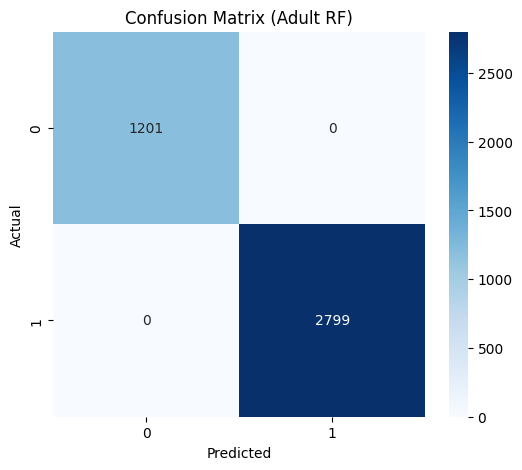

In [21]:
cm = confusion_matrix(

    y_test_a,

    adult_predictions

)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.title("Confusion Matrix (Adult RF)")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.savefig(

    "results/confusion_matrix_adult_rf.png",

    dpi=300

)

plt.show()

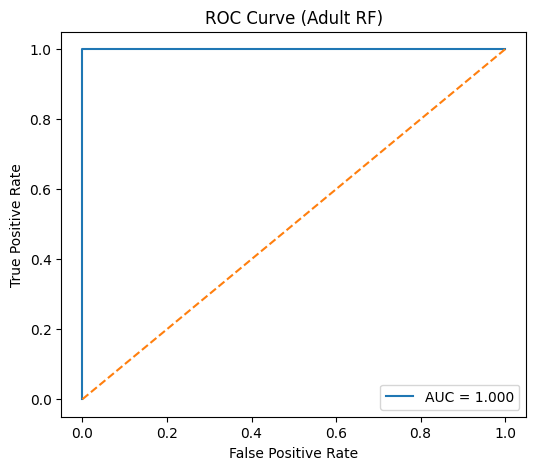

In [22]:
fpr,tpr,_ = roc_curve(

    y_test_a,

    rf_adult.predict_proba(X_test_a)[:,1]

)

roc_auc = auc(fpr,tpr)

plt.figure(figsize=(6,5))

plt.plot(

    fpr,

    tpr,

    label=f"AUC = {roc_auc:.3f}"

)

plt.plot([0,1],[0,1],"--")

plt.legend()

plt.title("ROC Curve (Adult RF)")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.savefig(

    "results/roc_adult_rf.png",

    dpi=300

)

plt.show()

In [23]:
# Feature Importance (Adult Dataset)

importance = pd.DataFrame({

    "Feature":adult_ml.drop(

        columns=["sleep_affected"]

    ).columns,

    "Importance":rf_adult.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance.head(10)

,Feature,Importance
11,Sleep disorder,0.528528
3,Sleep quality,0.410444
5,Blood pressure,0.007074
8,Physical activity,0.005611
2,Sleep duration,0.005101
9,Height,0.004752
27,screen_time_hours,0.004704
10,Weight,0.004676
6,Heart rate,0.004570
20,Average screen time,0.004410


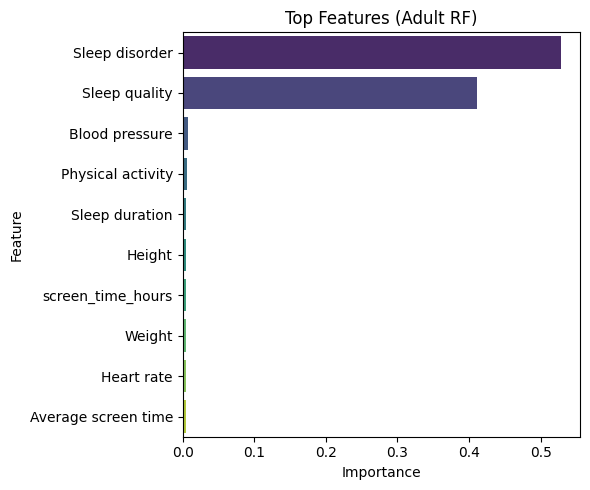

In [26]:
plt.figure(figsize=(6,5))

sns.barplot(

    data=importance.head(10),

    y="Feature",

    x="Importance",

    palette="viridis"

)

plt.title("Top Features (Adult RF)")

plt.tight_layout()

plt.savefig(

    "results/feature_importance_adult.png",

    dpi=300

)

plt.show()

In [27]:
# Random Forest (Kids Dataset)

rf_kids = RandomForestClassifier(

    n_estimators=200,

    max_depth=10,

    random_state=42

)

rf_kids.fit(

    X_train_k,

    y_train_k

)

kids_predictions = rf_kids.predict(

    X_test_k

)

In [28]:
print(

    "Kids Random Forest Accuracy :",

    accuracy_score(

        y_test_k,

        kids_predictions

    )

)

print()

print(

    classification_report(

        y_test_k,

        kids_predictions

    )

)

Kids Random Forest Accuracy : 1.0

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       952
           1       1.00      1.00      1.00       982

    accuracy                           1.00      1934
   macro avg       1.00      1.00      1.00      1934
weighted avg       1.00      1.00      1.00      1934



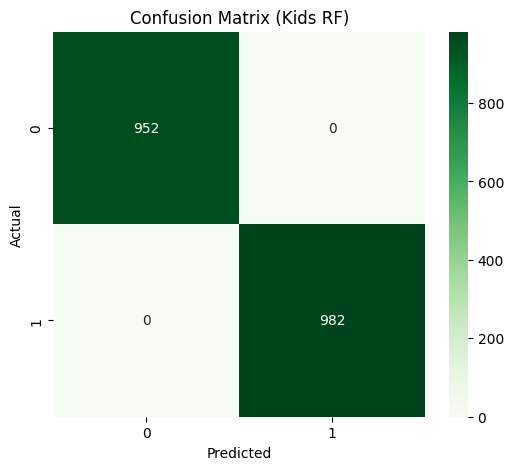

In [29]:
cm = confusion_matrix(

    y_test_k,

    kids_predictions

)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Greens"

)

plt.title("Confusion Matrix (Kids RF)")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.savefig(

    "results/confusion_matrix_kids_rf.png",

    dpi=300

)

plt.show()

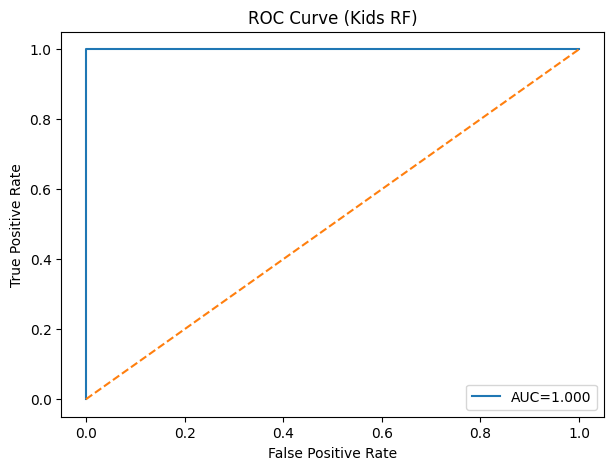

In [30]:
fpr,tpr,_ = roc_curve(

    y_test_k,

    rf_kids.predict_proba(X_test_k)[:,1]

)

roc_auc = auc(

    fpr,

    tpr

)

plt.figure(figsize=(7,5))

plt.plot(

    fpr,

    tpr,

    label=f"AUC={roc_auc:.3f}"

)

plt.plot([0,1],[0,1],"--")

plt.legend()

plt.title("ROC Curve (Kids RF)")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.savefig(

    "results/roc_kids_rf.png",

    dpi=300

)

plt.show()

In [31]:
# Feature Importance (Kids Dataset)

importance = pd.DataFrame({

    "Feature":kids_ml.drop(

        columns=["sleep_affected"]

    ).columns,

    "Importance":rf_kids.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

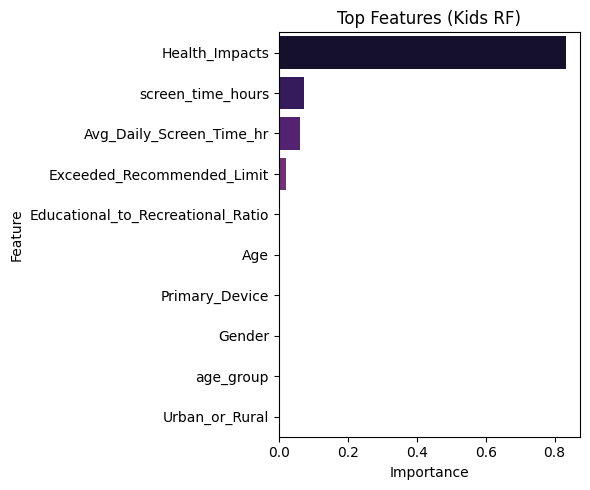

In [33]:
plt.figure(figsize=(6,5))

sns.barplot(

    data=importance.head(10),

    y="Feature",

    x="Importance",

    palette="magma"

)

plt.title("Top Features (Kids RF)")

plt.tight_layout()

plt.savefig(

    "results/feature_importance_kids.png",

    dpi=300

)

plt.show()

In [34]:
# TensorFlow Neural Network - Adult Dataset

adult_model = tf.keras.Sequential([

    Dense(64, activation="relu", input_shape=(X_train_a.shape[1],)),
    Dropout(0.3),

    Dense(32, activation="relu"),
    Dropout(0.2),

    Dense(16, activation="relu"),

    Dense(1, activation="sigmoid")

])

adult_model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]

)

adult_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,481 (17.50 KB)

 Trainable params: 4,481 (17.50 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
history_adult = adult_model.fit(

    X_train_a,

    y_train_a,

    validation_split=0.2,

    epochs=30,

    batch_size=32,

    verbose=1

)

Epoch 1/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8571 - loss: 0.2985 - val_accuracy: 0.9944 - val_loss: 0.0418
Epoch 2/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9721 - loss: 0.0703 - val_accuracy: 1.0000 - val_loss: 0.0066
Epoch 3/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9900 - loss: 0.0267 - val_accuracy: 1.0000 - val_loss: 8.6024e-04
Epoch 4/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9964 - loss: 0.0121 - val_accuracy: 1.0000 - val_loss: 2.3491e-04
Epoch 5/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9984 - loss: 0.0047 - val_accuracy: 1.0000 - val_loss: 6.7330e-05
Epoch 6/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9985 - loss: 0.0040 - val_accuracy: 1.0000 - val_loss: 2.5461e-05
Epoch 7/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9992 - loss: 0.0026 - val_accuracy: 1.0000 - val_loss: 1.5621e-05
Epoch 8/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9996 - loss: 0.001

In [36]:
adult_loss, adult_accuracy = adult_model.evaluate(

    X_test_a,

    y_test_a,

    verbose=0

)

print("Adult Neural Network Accuracy :", adult_accuracy)

Adult Neural Network Accuracy : 1.0


In [37]:
adult_predictions_nn = (

    adult_model.predict(X_test_a) > 0.5

).astype(int)

print(

classification_report(

    y_test_a,

    adult_predictions_nn

))

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1201
           1       1.00      1.00      1.00      2799

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



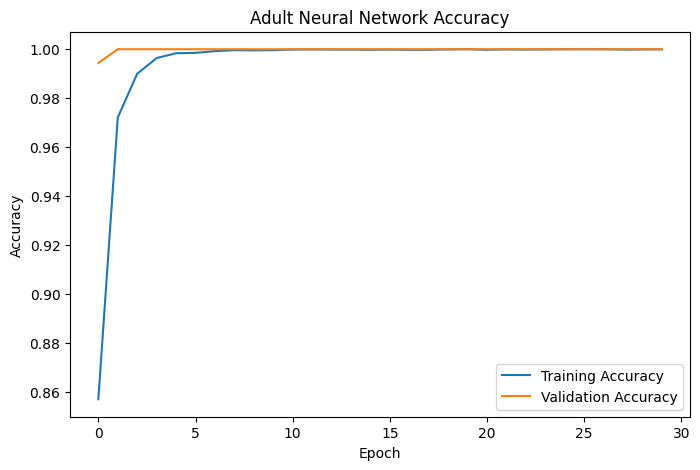

In [38]:
plt.figure(figsize=(8,5))

plt.plot(

    history_adult.history["accuracy"],

    label="Training Accuracy"

)

plt.plot(

    history_adult.history["val_accuracy"],

    label="Validation Accuracy"

)

plt.title("Adult Neural Network Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.savefig(

    "results/adult_nn_accuracy.png",

    dpi=300

)

plt.show()

In [39]:
# Neural Network - Kids Dataset

kids_model = tf.keras.Sequential([

    Dense(64, activation="relu", input_shape=(X_train_k.shape[1],)),
    Dropout(0.3),

    Dense(32, activation="relu"),
    Dropout(0.2),

    Dense(16, activation="relu"),

    Dense(1, activation="sigmoid")

])

kids_model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]

)

In [40]:
history_kids = kids_model.fit(

    X_train_k,

    y_train_k,

    validation_split=0.2,

    epochs=30,

    batch_size=32,

    verbose=1

)

Epoch 1/30
194/194 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6837 - loss: 0.5704 - val_accuracy: 0.8080 - val_loss: 0.4540
Epoch 2/30
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8657 - loss: 0.3383 - val_accuracy: 0.9198 - val_loss: 0.1889
Epoch 3/30
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9139 - loss: 0.2123 - val_accuracy: 0.9257 - val_loss: 0.1414
Epoch 4/30
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9310 - loss: 0.1663 - val_accuracy: 0.9451 - val_loss: 0.1063
Epoch 5/30
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9480 - loss: 0.1284 - val_accuracy: 0.9754 - val_loss: 0.0672
Epoch 6/30
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9596 - loss: 0.1008 - val_accuracy: 0.9800 - val_loss: 0.0496
Epoch 7/30
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9699 - loss: 0.0757 - val_accuracy: 0.9955 - val_loss: 0.0279
Epoch 8/30
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9842 - loss: 0.0504 - val_accuracy: 1.

In [41]:
kids_loss, kids_accuracy = kids_model.evaluate(

    X_test_k,

    y_test_k,

    verbose=0

)

print("Kids Neural Network Accuracy :", kids_accuracy)

Kids Neural Network Accuracy : 1.0


In [42]:
kids_predictions_nn = (

    kids_model.predict(X_test_k) > 0.5

).astype(int)

print(

classification_report(

    y_test_k,

    kids_predictions_nn

))

61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       952
           1       1.00      1.00      1.00       982

    accuracy                           1.00      1934
   macro avg       1.00      1.00      1.00      1934
weighted avg       1.00      1.00      1.00      1934



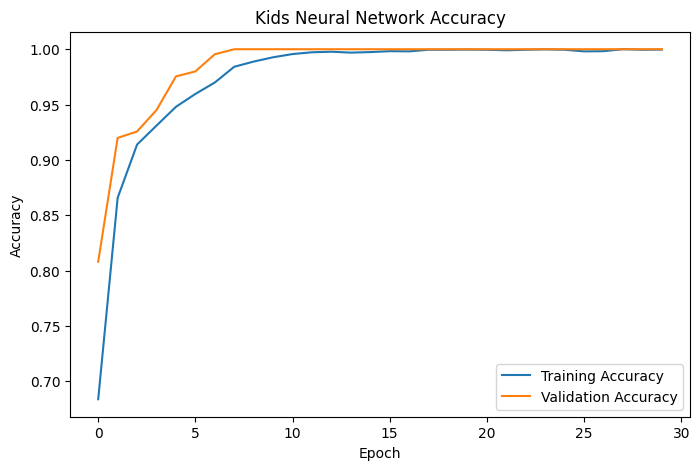

In [43]:
plt.figure(figsize=(8,5))

plt.plot(

    history_kids.history["accuracy"],

    label="Training Accuracy"

)

plt.plot(

    history_kids.history["val_accuracy"],

    label="Validation Accuracy"

)

plt.title("Kids Neural Network Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.savefig(

    "results/kids_nn_accuracy.png",

    dpi=300

)

plt.show()

In [44]:
# Model Performance Comparison

comparison = pd.DataFrame({

    "Dataset":[
        "Adult",
        "Adult",
        "Kids",
        "Kids"
    ],

    "Model":[
        "Random Forest",
        "Neural Network",
        "Random Forest",
        "Neural Network"
    ],

    "Accuracy":[
        accuracy_score(
            y_test_a,
            adult_predictions
        ),
        adult_accuracy,
        accuracy_score(
            y_test_k,
            kids_predictions
        ),
        kids_accuracy
    ]
})

comparison

,Dataset,Model,Accuracy
0,Adult,Random Forest,1.0
1,Adult,Neural Network,1.0
2,Kids,Random Forest,1.0
3,Kids,Neural Network,1.0


In [46]:
comparison = pd.DataFrame({

    "Dataset":[
        "Adult",
        "Adult",
        "Kids",
        "Kids"
    ],

    "Model":[
        "Random Forest",
        "Neural Network",
        "Random Forest",
        "Neural Network"
    ],

    "Accuracy":[
        accuracy_score(
            y_test_a,
            adult_predictions
        ),
        adult_accuracy,
        accuracy_score(
            y_test_k,
            kids_predictions
        ),
        kids_accuracy
    ]
})

comparison

,Dataset,Model,Accuracy
0,Adult,Random Forest,1.0
1,Adult,Neural Network,1.0
2,Kids,Random Forest,1.0
3,Kids,Neural Network,1.0


In [47]:
# Save Trained Models

adult_model.save(
    "models/adult_sleep_model.keras"
)

kids_model.save(
    "models/kids_sleep_model.keras"
)

print("TensorFlow Models Saved Successfully")

TensorFlow Models Saved Successfully


In [48]:
import joblib

joblib.dump(
    rf_adult,
    "models/adult_random_forest.pkl"
)

joblib.dump(
    rf_kids,
    "models/kids_random_forest.pkl"
)

print("Random Forest Models Saved Successfully")

Random Forest Models Saved Successfully


In [49]:
comparison.to_csv(
    "results/model_performance.csv",
    index=False
)

comparison

,Dataset,Model,Accuracy
0,Adult,Random Forest,1.0
1,Adult,Neural Network,1.0
2,Kids,Random Forest,1.0
3,Kids,Neural Network,1.0


In [50]:
from google.colab import files

files.download("models/adult_sleep_model.keras")
files.download("models/kids_sleep_model.keras")

files.download("models/adult_random_forest.pkl")
files.download("models/kids_random_forest.pkl")

files.download("results/model_performance.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>